In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn sentence-transformers wordcloud kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rohithsaikambhampati","key":"d348ed5914e391421aa58fd8efea6a45"}'}

In [3]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!ls /root/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d yasserh/twitter-tweets-sentiment-dataset
!unzip twitter-tweets-sentiment-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset
License(s): CC0-1.0
  0% 0.00/1.23M [00:00<?, ?B/s]
100% 1.23M/1.23M [00:00<00:00, 646MB/s]
Archive:  twitter-tweets-sentiment-dataset.zip
  inflating: Tweets.csv              


In [6]:
!ls

sample_data  Tweets.csv  twitter-tweets-sentiment-dataset.zip


In [7]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [9]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')

In [10]:
df["sentiment"].value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


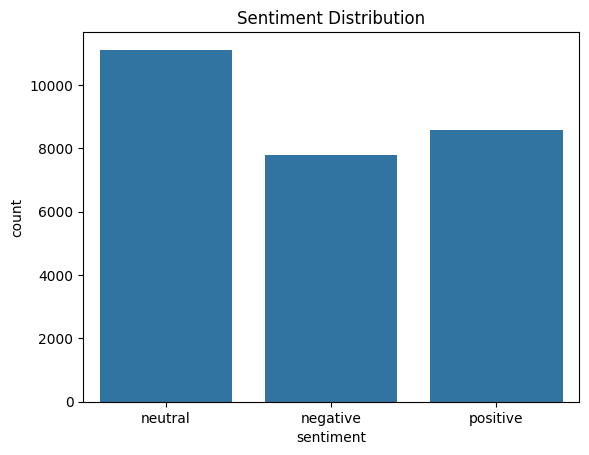

In [11]:
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()

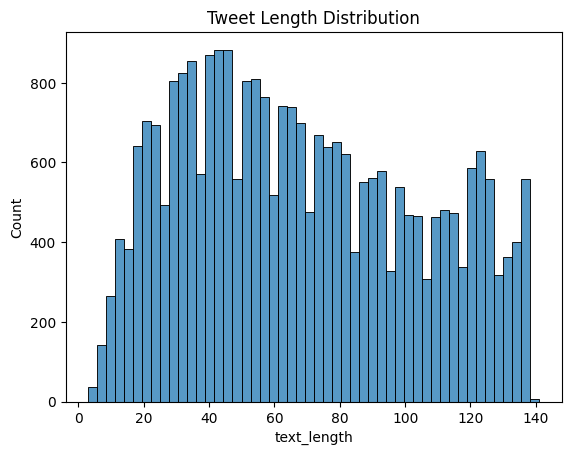

In [12]:
df["text_length"] = df["text"].astype(str).apply(len)

sns.histplot(df["text_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.show()

In [13]:
def clean_text(text):
    text = str(text).lower()
    # Apply specific negation replacements first with very strong and common sentiment terms
    text = text.replace("not worst", "excellent")
    text = text.replace("not bad", "great")
    text = text.replace("not okay", "excellent") # Changed from 'acceptable' to 'excellent'
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

,textID,text,selected_text,sentiment,text_length,clean_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36,id have responded if i were going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46,sooo sad i will miss you here in san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,25,my boss is bullying me
3,9642c003ef,what interview! leave me alone,leave me alone,negative,31,what interview leave me alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75,sons of why couldnt they put them on the relea...


In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df["clean_text"].tolist(),
    show_progress_bar=True
)

embeddings.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/859 [00:00<?, ?it/s]

(27481, 384)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

In [16]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [17]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.71      0.69      0.70      1556
     neutral       0.65      0.70      0.67      2224
    positive       0.76      0.69      0.72      1717

    accuracy                           0.69      5497
   macro avg       0.70      0.69      0.70      5497
weighted avg       0.70      0.69      0.69      5497



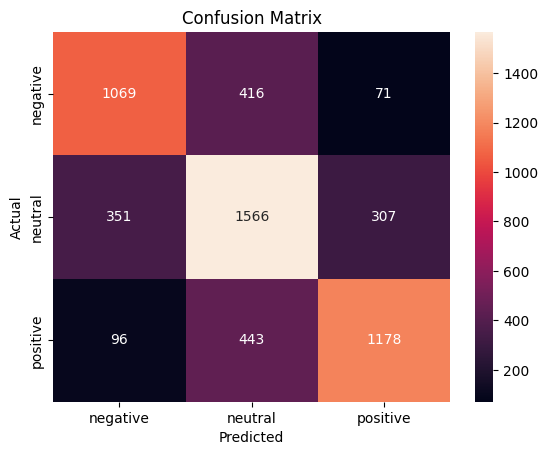

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred);

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
custom_tweets = [
    "I absolutely love this phone!",
    "This service is horrible",
    "It is not  okay, nothing special",
    "worst experience ever",
    "Very happy with the results",
    "not worst experience ever"

]

cleaned = [clean_text(t) for t in custom_tweets]
custom_embeddings = model.encode(cleaned)

predictions = clf.predict(custom_embeddings)

for t, p in zip(custom_tweets, predictions):
    print(f"Tweet: {t}")
    print(f"Predicted Sentiment: {p}")
    print("-"*40)

Tweet: I absolutely love this phone!
Predicted Sentiment: positive
----------------------------------------
Tweet: This service is horrible
Predicted Sentiment: negative
----------------------------------------
Tweet: It is not  okay, nothing special
Predicted Sentiment: negative
----------------------------------------
Tweet: worst experience ever
Predicted Sentiment: negative
----------------------------------------
Tweet: Very happy with the results
Predicted Sentiment: positive
----------------------------------------
Tweet: not worst experience ever
Predicted Sentiment: positive
----------------------------------------
